# Fiber optic and the electronic check

Internet service has three phrases.

| Internet | Customers | Leavers | Leave rate |
|---|---:|---:|---:|
| Fiber optic | 3096 | 1297 | $1297/3096$ |
| DSL | 2421 | 459 | $51/269$ |
| No | 1526 | 113 | $113/1526$ |

$3096 + 2421 + 1526 = 7043$ and $1297 + 459 + 113 = 1869$. Also $459/2421 = 51/269$.

Payment method has four phrases. Electronic check is the largest leave rate: 1071 of 2365, which is $1071/2365$. The other three are mailed check $77/403$ (308 of 1612), bank transfer $129/772$ (258 of 1544), and credit card $116/761$ (232 of 1522). Those four leaver counts add to 1869.

Fiber optic still depends on the contract. Among fiber customers the leave counts are 1162 of 2128 on month-to-month ($83/152$), 104 of 539 on one year, and 31 of 429 on two year.


In [1]:
# Locate the telco table beside this notebook, or under the course root.
import csv
from pathlib import Path

def data_path():
    here = Path.cwd()
    name = "Telco-Customer-Churn.csv"
    for folder in [here, *here.parents]:
        nested = folder / "16-Customer Churn" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists():
            return direct
    raise FileNotFoundError(name)

def read_customers():
    with data_path().open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))
# Internet rates, payment rates, and fiber split by contract.
from fractions import Fraction

rows = read_customers()

def rate(predicate):
    chosen = [row for row in rows if predicate(row)]
    left = sum(row["Churn"] == "Yes" for row in chosen)
    return len(chosen), left, Fraction(left, len(chosen))

internet = {
    "Fiber optic": (3096, 1297, Fraction(1297, 3096)),
    "DSL": (2421, 459, Fraction(51, 269)),
    "No": (1526, 113, Fraction(113, 1526)),
}
for name, expected in internet.items():
    got = rate(lambda row, name=name: row["InternetService"] == name)
    print("internet", name, got)
    assert got == expected
payments = {
    "Electronic check": (2365, 1071, Fraction(1071, 2365)),
    "Mailed check": (1612, 308, Fraction(77, 403)),
    "Bank transfer (automatic)": (1544, 258, Fraction(129, 772)),
    "Credit card (automatic)": (1522, 232, Fraction(116, 761)),
}
for name, expected in payments.items():
    got = rate(lambda row, name=name: row["PaymentMethod"] == name)
    print("pay", name, got)
    assert got == expected
assert sum(item[1] for item in payments.values()) == 1869
fiber_contract = {
    "Month-to-month": (2128, 1162, Fraction(83, 152)),
    "One year": (539, 104, Fraction(104, 539)),
    "Two year": (429, 31, Fraction(31, 429)),
}
for name, expected in fiber_contract.items():
    got = rate(
        lambda row, name=name: row["InternetService"] == "Fiber optic" and row["Contract"] == name
    )
    print("fiber", name, got)
    assert got == expected


internet Fiber optic (3096, 1297, Fraction(1297, 3096))
internet DSL (2421, 459, Fraction(51, 269))
internet No (1526, 113, Fraction(113, 1526))
pay Electronic check (2365, 1071, Fraction(1071, 2365))
pay Mailed check (1612, 308, Fraction(77, 403))
pay Bank transfer (automatic) (1544, 258, Fraction(129, 772))
pay Credit card (automatic) (1522, 232, Fraction(116, 761))
fiber Month-to-month (2128, 1162, Fraction(83, 152))
fiber One year (539, 104, Fraction(104, 539))
fiber Two year (429, 31, Fraction(31, 429))


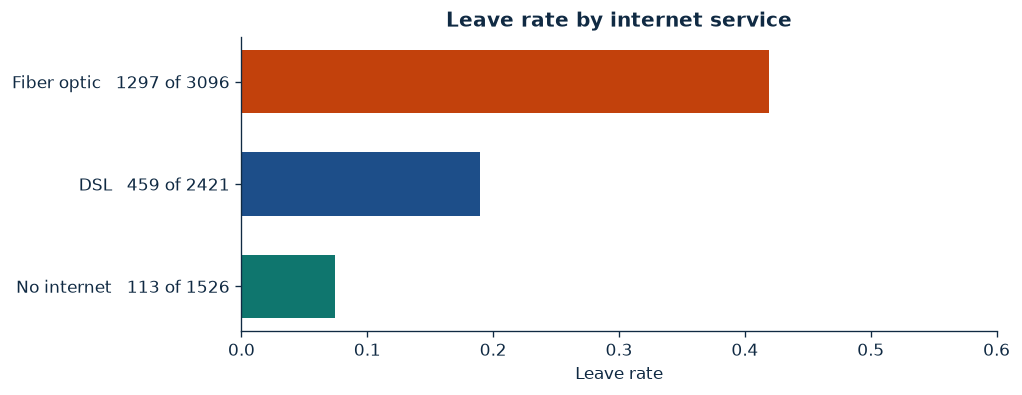

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
    "axes.titlecolor": "#102a43",
})
# Leave rate by internet service.
from fractions import Fraction
labels = [
    "Fiber optic   1297 of 3096",
    "DSL   459 of 2421",
    "No internet   113 of 1526",
]
rates = [
    float(Fraction(1297, 3096)),
    float(Fraction(459, 2421)),
    float(Fraction(113, 1526)),
]
colors = ["#c2410c", "#1d4e89", "#0f766e"]
positions = [2, 1, 0]
figure, axis = plt.subplots(figsize=(8.6, 3.4))
axis.barh(positions, rates, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 0.6)
axis.set_xlabel("Leave rate")
axis.set_title("Leave rate by internet service")
figure.tight_layout()


## Pitfall

The fiber row in the chart is $1297/3096$. The two-year fiber count is $31/429$. A sentence that says "fiber customers leave" is averaging a month-to-month fiber rate of $83/152$ with a two-year fiber rate of $31/429$.

## Summary

Fiber optic leave rate $1297/3096$, DSL $51/269$, no internet $113/1526$. Electronic check leave rate $1071/2365$. Fiber on a two-year contract leaves at $31/429$.
